# ST-GNN Model Results

Visualizza i risultati del modello salvato da `python main.py`.

> **Pre-requisito**: eseguire `python main.py` dalla root del progetto.

In [1]:
import sys, json, os
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xarray as xr

from main import _normalize_dataset
from physiq_pv.model.st_gnn import STGNN
from physiq_pv.model.graph_builder import build_graph
from physiq_pv.data.dataset import PVDataset
from physiq_pv.data.quality_score import compute_qs
from physiq_pv.data.load_kwp import load_kwp
from physiq_pv.data.sentinel_hourly_loader import load_sentinel_hourly, merge_with_weather
from torch.utils.data import DataLoader

sns.set_theme(style='darkgrid')
CKPT = '../checkpoints'

with open(f'{CKPT}/model_config.json') as f:
    cfg = json.load(f)
with open(f'{CKPT}/loss_history.json') as f:
    _lh = json.load(f)
loss_history     = _lh['train'] if isinstance(_lh, dict) else _lh
val_loss_history = _lh.get('val', []) if isinstance(_lh, dict) else []

calib_path = f'{CKPT}/pv_calibration.json'
pv_calibration = {
    'enabled': False,
    'slope': 1.0,
    'intercept': 0.0,
    'daytime_ghi_threshold': 0.01,
}
if os.path.exists(calib_path):
    with open(calib_path) as f:
        pv_calibration = json.load(f)
    if pv_calibration.get('enabled', False):
        print(
            f"PV calibration loaded: slope={pv_calibration['slope']:.4f}, "
            f"intercept={pv_calibration['intercept']:+.4f}, "
            f"day_threshold={pv_calibration.get('daytime_ghi_threshold', 0.01):.3f}"
        )

model = STGNN(**cfg)
model.load_state_dict(torch.load(f'{CKPT}/model.pt', map_location='cpu'))
model.eval()
print(f'Model: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Train loss: {[round(l, 4) for l in loss_history]}')
if val_loss_history:
    print(f'Val   loss: {[round(l, 4) for l in val_loss_history]}')
    print(f'Best val:   {min(val_loss_history):.4f} @ epoch {val_loss_history.index(min(val_loss_history))+1}')

# Load Sentinel hourly data (1116 plants, 5743 hours, 2019-03 to 2019-12)
print('\nLoading Sentinel hourly data...')
ds = load_sentinel_hourly(
    sentinel_dir='/data/SentinelPV/energy_data/piemonte_energy_data/single_ups',
    year=2019,
    plant_mapping_path='../data/plant_mapping.csv',
    energy_coords_path='../data/energy_with_coordinates.csv',
)
ds = merge_with_weather(ds, pvgis_path='../data/piedmont_pvgis_2019.nc')
ds = _normalize_dataset(ds)
qs = compute_qs(ds)
edge_index, edge_weight = build_graph(ds['lat'].values, ds['lon'].values, max_dist_km=20.0)
print(f'Graph: {ds.sizes["plant"]} nodes, {edge_index.shape[1]} edges')

kwp = None
if os.path.exists('../data/plant_mapping.csv') and os.path.exists('../data/energy_with_coordinates.csv'):
    kwp = load_kwp('../data/plant_mapping.csv', '../data/energy_with_coordinates.csv', ds.sizes['plant'])
    print(f'Real kWp loaded: {int(np.sum(np.isfinite(kwp)))}/{ds.sizes["plant"]} plants  range=[{np.nanmin(kwp):.0f}, {np.nanmax(kwp):.0f}] kW')

dataset = PVDataset(ds, qs, kwp=kwp)
loader  = DataLoader(dataset, batch_size=64, shuffle=False)
print(f'Dataset: {len(dataset)} samples  ({ds.sizes["plant"]} plants x {ds.sizes["time"]} hours)')

PV calibration loaded: slope=0.9473, intercept=-0.0006, day_threshold=0.010
Model: 156,435 params
Train loss: [0.0839, 0.0569, 0.0541, 0.0525, 0.052, 0.0508, 0.0512, 0.0501, 0.0497, 0.0489]
Val   loss: [0.0666, 0.0585, 0.0587, 0.0576, 0.056, 0.0576, 0.055, 0.0536, 0.0536, 0.0594]
Best val:   0.0536 @ epoch 8

Loading Sentinel hourly data...


/home/apedalino/physiq_pv/physiq_pv/model/patchtst_encoder.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  Found 1116 Sentinel files for year 2019
  Loading 1116 UPN plants...
  Unique timestamps across all plants: 5743
  Stacked: 1116 plants × 5743 timesteps (aligned to common time grid)
  ✅ Dataset: 1116 plants × 5743 hours
  Matching 1116 plants to PVGIS grid (1149 locations)...
  Time alignment: Sentinel 5743 hours, PVGIS 8760 hours
  Merged weather variables: temperature_2m, solar_irradiance_poa, wind_speed_10m
Graph: 1116 nodes, 113312 edges
Real kWp loaded: 94/1116 plants  range=[3, 4997] kW
Dataset: 5718 samples  (1116 plants x 5743 hours)


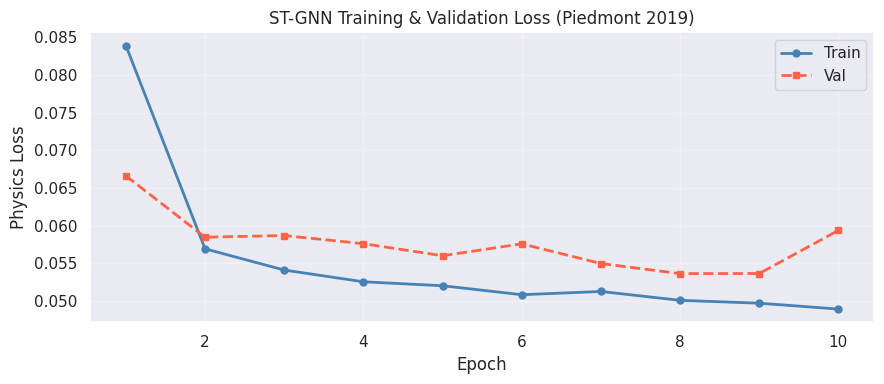

=== LOSS CURVE ===
  Epoch  1: train=0.0839  val=0.0666
  Epoch  2: train=0.0569  val=0.0585  (+32.2%)
  Epoch  3: train=0.0541  val=0.0587  (+5.0%)
  Epoch  4: train=0.0525  val=0.0576  (+2.9%)
  Epoch  5: train=0.0520  val=0.0560  (+1.0%)
  Epoch  6: train=0.0508  val=0.0576  (+2.3%)
  Epoch  7: train=0.0512  val=0.0550  (-0.8%)
  Epoch  8: train=0.0501  val=0.0536  (+2.3%)
  Epoch  9: train=0.0497  val=0.0536  (+0.8%)
  Epoch 10: train=0.0489  val=0.0594  (+1.6%)
  Total drop: 41.7%
  Best val epoch: 8  val=0.0536


In [2]:
# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(loss_history) + 1)
ax.plot(epochs, loss_history, 'o-', color='steelblue', linewidth=2, markersize=5, label='Train')
if val_loss_history:
    ax.plot(range(1, len(val_loss_history) + 1), val_loss_history, 's--', color='tomato', linewidth=2, markersize=5, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Physics Loss')
ax.set_title('ST-GNN Training & Validation Loss (Piedmont 2019)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== LOSS CURVE ===")
for i, v in enumerate(loss_history):
    drop = f"  ({(loss_history[i-1]-v)/loss_history[i-1]*100:+.1f}%)" if i > 0 else ""
    val_str = f"  val={val_loss_history[i]:.4f}" if i < len(val_loss_history) else ""
    print(f"  Epoch {i+1:>2}: train={v:.4f}{val_str}{drop}")
total_drop = (loss_history[0] - loss_history[-1]) / loss_history[0] * 100
print(f"  Total drop: {total_drop:.1f}%")
if val_loss_history:
    best_ep = val_loss_history.index(min(val_loss_history)) + 1
    print(f"  Best val epoch: {best_ep}  val={min(val_loss_history):.4f}")

Inference on: cuda


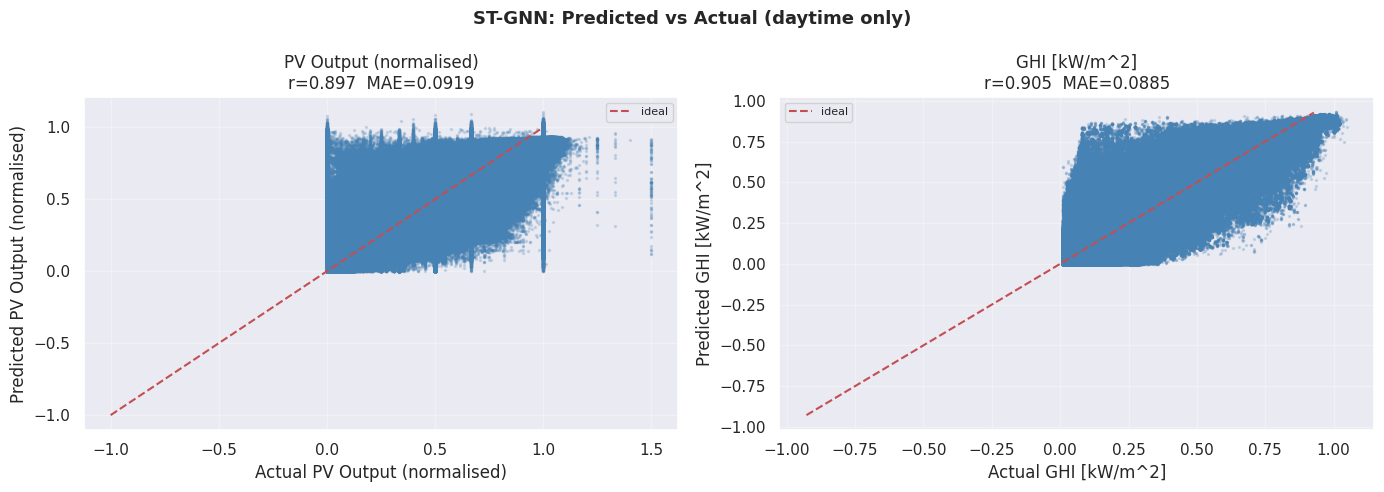


=== SCATTER METRICS (daytime, n=3,061,186) ===
  PV Output (normalised):
    r=0.897  MAE=0.0919  RMSE=0.1444  bias=+0.0025
    actual  range: [0.000, 1.500]  mean=0.366
    predicted range: [-0.001, 1.106]  mean=0.368
    negative predictions: 96748 (3.2%)
  GHI [kW/m^2]:
    r=0.905  MAE=0.0885  RMSE=0.1183  bias=+0.0210
    actual  range: [0.011, 1.049]  mean=0.342
    predicted range: [0.000, 0.930]  mean=0.363
    negative predictions: 0 (0.0%)


In [3]:
# Inference: collect pred vs actual
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(DEVICE)
ei = edge_index.to(DEVICE)
ew = edge_weight.to(DEVICE)
print(f'Inference on: {DEVICE}')

if 'pv_calibration' not in globals():
    pv_calibration = {'enabled': False, 'slope': 1.0, 'intercept': 0.0, 'daytime_ghi_threshold': 0.01}

daytime_ghi_threshold = float(pv_calibration.get('daytime_ghi_threshold', 0.01))
calib_enabled = bool(pv_calibration.get('enabled', False))
calib_slope = float(pv_calibration.get('slope', 1.0))
calib_intercept = float(pv_calibration.get('intercept', 0.0))

all_pred_pv, all_true_pv = [], []
all_pred_ghi, all_true_ghi = [], []

with torch.no_grad():
    for i, (x, y_ghi, y_pv, qs_b, eta) in enumerate(loader):
        if i >= 200:
            break
        pg, pp = model(x.to(DEVICE), ei, ew)
        pp_np = pp.cpu().numpy()
        if calib_enabled:
            pp_np = calib_slope * pp_np + calib_intercept
        all_pred_pv.append(pp_np)
        all_true_pv.append(y_pv.numpy())
        all_pred_ghi.append(pg.cpu().numpy())
        all_true_ghi.append(y_ghi.numpy())

pred_pv  = np.concatenate(all_pred_pv).ravel()
true_pv  = np.concatenate(all_true_pv).ravel()
pred_ghi = np.concatenate(all_pred_ghi).ravel()
true_ghi = np.concatenate(all_true_ghi).ravel()

day_mask   = true_ghi > daytime_ghi_threshold
pred_pv_d, true_pv_d   = pred_pv[day_mask],  true_pv[day_mask]
pred_ghi_d, true_ghi_d = pred_ghi[day_mask], true_ghi[day_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (p, t, label) in zip(axes, [
    (pred_pv_d,  true_pv_d,  'PV Output (normalised)'),
    (pred_ghi_d, true_ghi_d, 'GHI [kW/m^2]'),
]):
    lim = max(np.percentile(np.abs(t), 99), np.percentile(np.abs(p), 99))
    ax.scatter(t, p, s=2, alpha=0.2, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='ideal')
    corr = float(np.corrcoef(t, p)[0, 1])
    mae  = float(np.mean(np.abs(t - p)))
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}\nr={corr:.3f}  MAE={mae:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('ST-GNN: Predicted vs Actual (daytime only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

def _metrics(p, t, name):
    corr  = float(np.corrcoef(t, p)[0, 1])
    mae   = float(np.mean(np.abs(t - p)))
    rmse  = float(np.sqrt(np.mean((t - p)**2)))
    bias  = float(np.mean(p - t))
    neg   = int((p < 0).sum())
    print(f"  {name}:")
    print(f"    r={corr:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}")
    print(f"    actual  range: [{t.min():.3f}, {t.max():.3f}]  mean={t.mean():.3f}")
    print(f"    predicted range: [{p.min():.3f}, {p.max():.3f}]  mean={p.mean():.3f}")
    print(f"    negative predictions: {neg} ({neg/len(p)*100:.1f}%)")

print(f"\n=== SCATTER METRICS (daytime, n={day_mask.sum():,}) ===")
_metrics(pred_pv_d,  true_pv_d,  "PV Output (normalised)")
_metrics(pred_ghi_d, true_ghi_d, "GHI [kW/m^2]")

=== TIME SERIES METRICS ===
  Plant    0: r=0.984  MAE=0.0539  RMSE=0.0882  bias=-0.0364
             actual  peak=1.053  mean=0.295
             predicted peak=0.891  mean=0.258  amp_ratio=0.85
  Plant  500: r=0.980  MAE=0.0425  RMSE=0.0743  bias=-0.0079
             actual  peak=1.029  mean=0.247
             predicted peak=0.890  mean=0.239  amp_ratio=0.86
  Plant 1115: r=0.970  MAE=0.0448  RMSE=0.0791  bias=+0.0247
             actual  peak=0.993  mean=0.203
             predicted peak=0.893  mean=0.228  amp_ratio=0.90


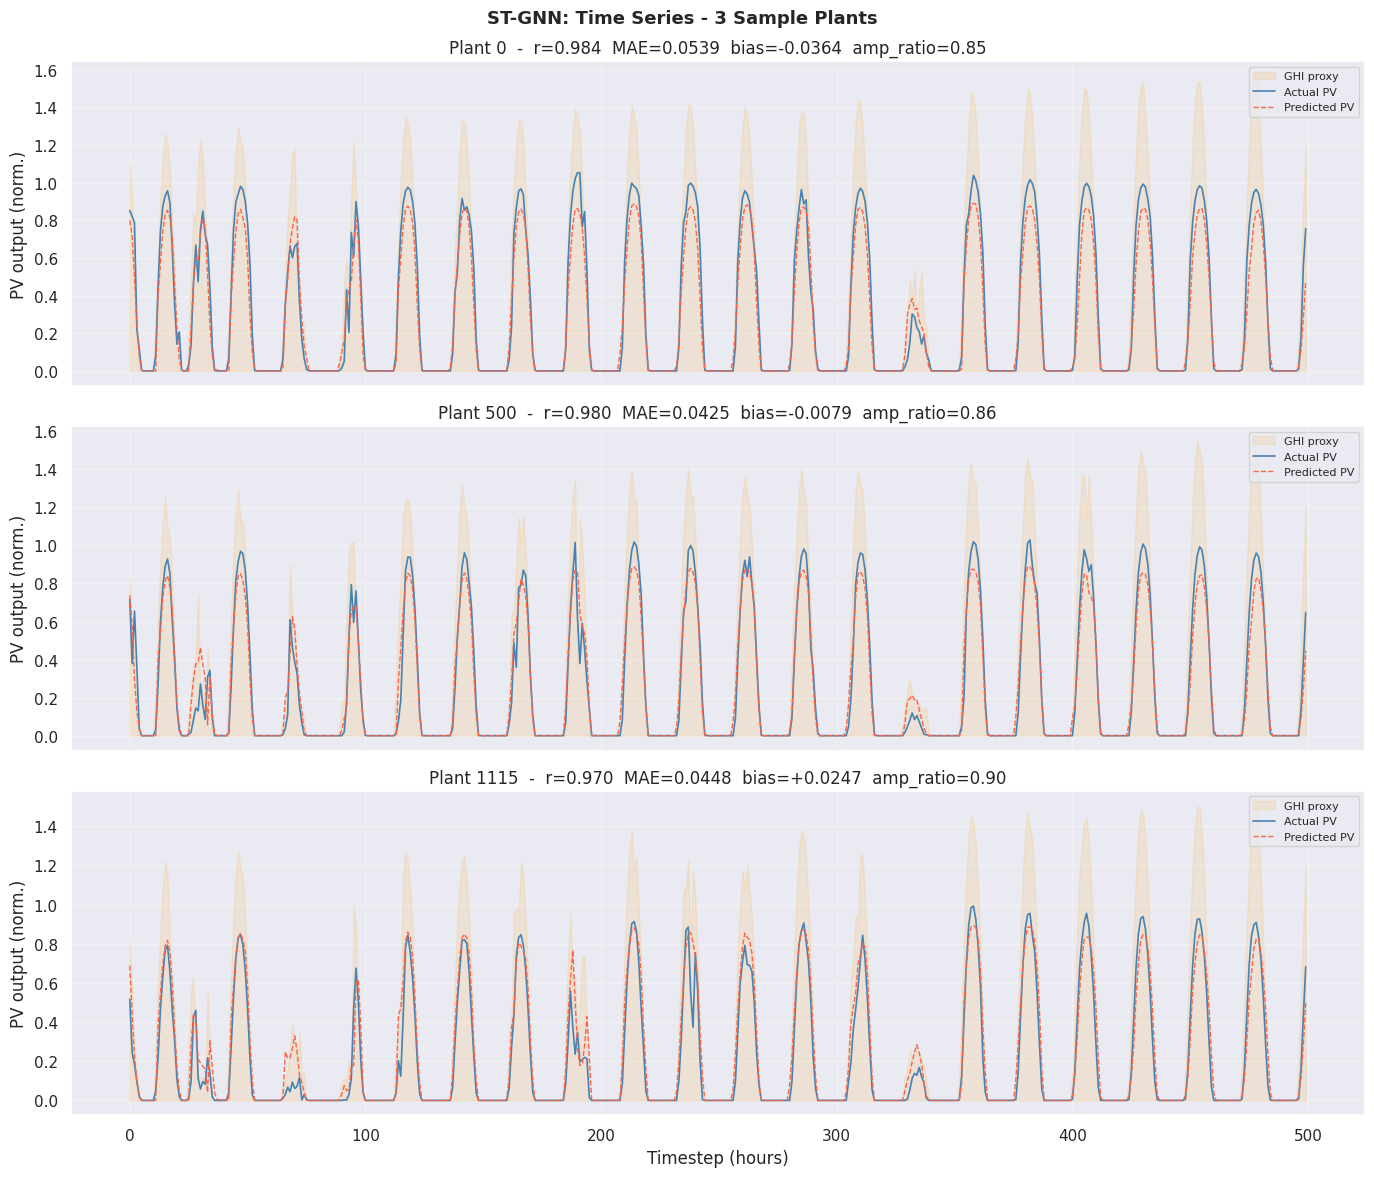

In [4]:
# Time series: 3 sample plants (spread across fleet)
T_SHOW = 500
sample_plant_ids = [0, 500, 1115]

if 'pv_calibration' not in globals():
    pv_calibration = {'enabled': False, 'slope': 1.0, 'intercept': 0.0, 'daytime_ghi_threshold': 0.01}

calib_enabled = bool(pv_calibration.get('enabled', False))
calib_slope = float(pv_calibration.get('slope', 1.0))
calib_intercept = float(pv_calibration.get('intercept', 0.0))

seq_pred_pv  = {p: [] for p in sample_plant_ids}
seq_true_pv  = {p: [] for p in sample_plant_ids}
seq_true_ghi = {p: [] for p in sample_plant_ids}

with torch.no_grad():
    for i, (x, y_ghi, y_pv, qs_b, eta) in enumerate(loader):
        if i * loader.batch_size >= T_SHOW:
            break
        pg, pp = model(x.to(DEVICE), ei, ew)
        pp_np = pp.cpu().numpy()
        if calib_enabled:
            pp_np = calib_slope * pp_np + calib_intercept
        for p in sample_plant_ids:
            seq_pred_pv[p].append(pp_np[:, p])
            seq_true_pv[p].append(y_pv[:, p].numpy())
            seq_true_ghi[p].append(y_ghi[:, p].numpy())

fig, axes = plt.subplots(len(sample_plant_ids), 1,
                         figsize=(14, 4 * len(sample_plant_ids)), sharex=True)
print("=== TIME SERIES METRICS ===")
for ax, p in zip(axes, sample_plant_ids):
    t_pv  = np.concatenate(seq_true_pv[p])[:T_SHOW]
    p_pv  = np.concatenate(seq_pred_pv[p])[:T_SHOW]
    t_ghi = np.concatenate(seq_true_ghi[p])[:T_SHOW]
    steps = np.arange(len(t_pv))

    corr = float(np.corrcoef(t_pv, p_pv)[0, 1]) if t_pv.std() > 0 else float('nan')
    mae  = float(np.mean(np.abs(t_pv - p_pv)))
    rmse = float(np.sqrt(np.mean((t_pv - p_pv)**2)))
    bias = float(np.mean(p_pv - t_pv))
    amp_ratio = float(p_pv.max() / t_pv.max()) if t_pv.max() > 0 else float('nan')

    ax.fill_between(steps, 0, t_ghi * 2, alpha=0.12, color='orange', label='GHI proxy')
    ax.plot(steps, t_pv, color='steelblue', linewidth=1.2, label='Actual PV')
    ax.plot(steps, p_pv, color='tomato', linewidth=1.0, linestyle='--', label='Predicted PV')
    ax.set_ylabel('PV output (norm.)')
    ax.set_title(f'Plant {p}  -  r={corr:.3f}  MAE={mae:.4f}  bias={bias:+.4f}  amp_ratio={amp_ratio:.2f}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f"  Plant {p:>4}: r={corr:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}")
    print(f"             actual  peak={t_pv.max():.3f}  mean={t_pv.mean():.3f}")
    print(f"             predicted peak={p_pv.max():.3f}  mean={p_pv.mean():.3f}  amp_ratio={amp_ratio:.2f}")

axes[-1].set_xlabel('Timestep (hours)')
plt.suptitle('ST-GNN: Time Series - 3 Sample Plants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Quality Score

In [5]:
# Diagnostic: timesteps per month (verifica gap nei CSV Sentinel)
import pandas as pd
times = pd.DatetimeIndex(ds['time'].values)
monthly_counts = pd.Series(1, index=times).resample('ME').count()
print("Timesteps per month (0 = mese assente nei CSV Sentinel):")
for mo, cnt in monthly_counts.items():
    bar = '#' * (cnt // 20)
    expected = mo.days_in_month * 24
    pct = cnt / expected * 100
    print(f"  {mo.strftime('%b %Y')}: {cnt:>4}h / {expected}h ({pct:4.0f}%)  {bar}")

Timesteps per month (0 = mese assente nei CSV Sentinel):
  Mar 2019:  694h / 744h (  93%)  ##################################
  Apr 2019:  683h / 720h (  95%)  ##################################
  May 2019:  694h / 744h (  93%)  ##################################
  Jun 2019:    0h / 720h (   0%)  
  Jul 2019:  744h / 744h ( 100%)  #####################################
  Aug 2019:    0h / 744h (   0%)  
  Sep 2019:  720h / 720h ( 100%)  ####################################
  Oct 2019:  744h / 744h ( 100%)  #####################################
  Nov 2019:  720h / 720h ( 100%)  ####################################
  Dec 2019:  744h / 744h ( 100%)  #####################################


=== QUALITY SCORE REPORT ===
  Shape: 1116 plants x 5743 timesteps
  Valid QS values: 2,719,604 / 6,409,188 (42.4%)
  Daytime valid:   2,369,755 (37.0%)

  GLOBAL (all valid):
    mean=0.653  median=0.743  std=0.252
    p10=0.000  p25=0.685  p75=0.781  p90=0.802

  DAYTIME ONLY:
    mean=0.726  median=0.751  std=0.106

  PER-PLANT (daytime mean, 1 plants no daytime data):
    min=0.111  max=0.804  mean=0.719  std=0.103
    plants QS>0.7: 907  QS 0.5-0.7: 151  QS<0.5: 57  no data: 1

  MONTHLY fleet mean (daytime only):
    Mar: 0.777  #######################
    Apr: 0.753  ######################
    May: 0.732  #####################
    Jun: NaN  (no data in Sentinel CSVs)
    Jul: 0.735  ######################
    Aug: NaN  (no data in Sentinel CSVs)
    Sep: 0.715  #####################
    Oct: 0.684  ####################
    Nov: 0.703  #####################
    Dec: 0.689  ####################


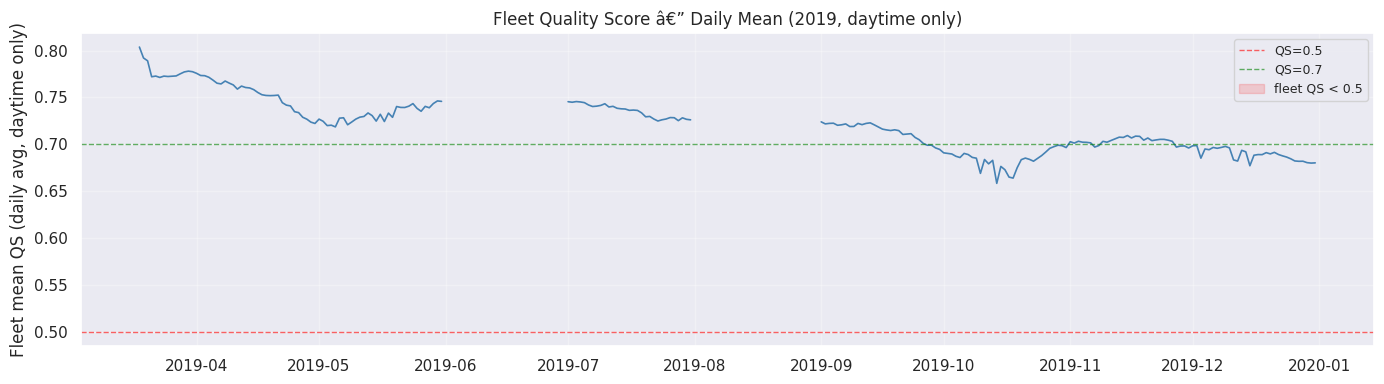

In [6]:
import pandas as pd
import warnings

qs_arr = qs.values                          # (N, T)
lats   = ds['lat'].values
lons   = ds['lon'].values
times  = pd.DatetimeIndex(ds['time'].values)
N, T   = qs_arr.shape

# Per-plant mean QS (daytime only: solar_irradiance_poa > 50 W/m^2)
poa    = ds['solar_irradiance_poa'].values  # (N, T)  W/m^2
day    = poa > 50.0
qs_day = np.where(day, qs_arr, np.nan)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    qs_plant_mean = np.nanmean(qs_day, axis=1)  # (N,) â€” NaN if plant has no daytime QS

# Fleet daily mean QS â€” daytime only (excludes spurious nighttime readings)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    qs_fleet_hourly = pd.Series(np.nanmean(qs_day, axis=0), index=times)
qs_fleet_daily  = qs_fleet_hourly.resample('1D').mean()
qs_monthly = qs_fleet_hourly.resample('ME').mean()

# --- Text report ---
qs_valid     = qs_arr[~np.isnan(qs_arr)]
qs_day_valid = qs_day[~np.isnan(qs_day)]
pm_valid     = qs_plant_mean[~np.isnan(qs_plant_mean)]
n_nan_plants = int(np.isnan(qs_plant_mean).sum())

print("=== QUALITY SCORE REPORT ===")
print(f"  Shape: {N} plants x {T} timesteps")
print(f"  Valid QS values: {len(qs_valid):,} / {qs_arr.size:,} ({len(qs_valid)/qs_arr.size*100:.1f}%)")
print(f"  Daytime valid:   {len(qs_day_valid):,} ({len(qs_day_valid)/qs_arr.size*100:.1f}%)")
print(f"\n  GLOBAL (all valid):")
print(f"    mean={np.nanmean(qs_valid):.3f}  median={np.nanmedian(qs_valid):.3f}  std={np.nanstd(qs_valid):.3f}")
print(f"    p10={np.nanpercentile(qs_valid,10):.3f}  p25={np.nanpercentile(qs_valid,25):.3f}"
      f"  p75={np.nanpercentile(qs_valid,75):.3f}  p90={np.nanpercentile(qs_valid,90):.3f}")
print(f"\n  DAYTIME ONLY:")
print(f"    mean={np.nanmean(qs_day_valid):.3f}  median={np.nanmedian(qs_day_valid):.3f}  std={np.nanstd(qs_day_valid):.3f}")
print(f"\n  PER-PLANT (daytime mean, {n_nan_plants} plants no daytime data):")
if len(pm_valid) > 0:
    print(f"    min={pm_valid.min():.3f}  max={pm_valid.max():.3f}"
          f"  mean={pm_valid.mean():.3f}  std={pm_valid.std():.3f}")
    print(f"    plants QS>0.7: {(pm_valid>0.7).sum()}"
          f"  QS 0.5-0.7: {((pm_valid>=0.5)&(pm_valid<=0.7)).sum()}"
          f"  QS<0.5: {(pm_valid<0.5).sum()}"
          f"  no data: {n_nan_plants}")
print(f"\n  MONTHLY fleet mean (daytime only):")
for mo, val in qs_monthly.items():
    if np.isnan(val):
        print(f"    {mo.strftime('%b'):>3}: NaN  (no data in Sentinel CSVs)")
    else:
        bar = '#' * int(val * 30)
        print(f"    {mo.strftime('%b'):>3}: {val:.3f}  {bar}")

# --- Fleet QS daily time series ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(qs_fleet_daily.index, qs_fleet_daily.values, linewidth=1.2, color='steelblue')
ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, linewidth=1, label='QS=0.5')
ax.axhline(0.7, color='green',  linestyle='--', alpha=0.6, linewidth=1, label='QS=0.7')
ax.fill_between(qs_fleet_daily.index, qs_fleet_daily.values, 0,
                where=qs_fleet_daily.values < 0.5, alpha=0.15, color='red', label='fleet QS < 0.5')
ax.set_ylabel('Fleet mean QS (daily avg, daytime only)')
ax.set_title('Fleet Quality Score â€” Daily Mean (2019, daytime only)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

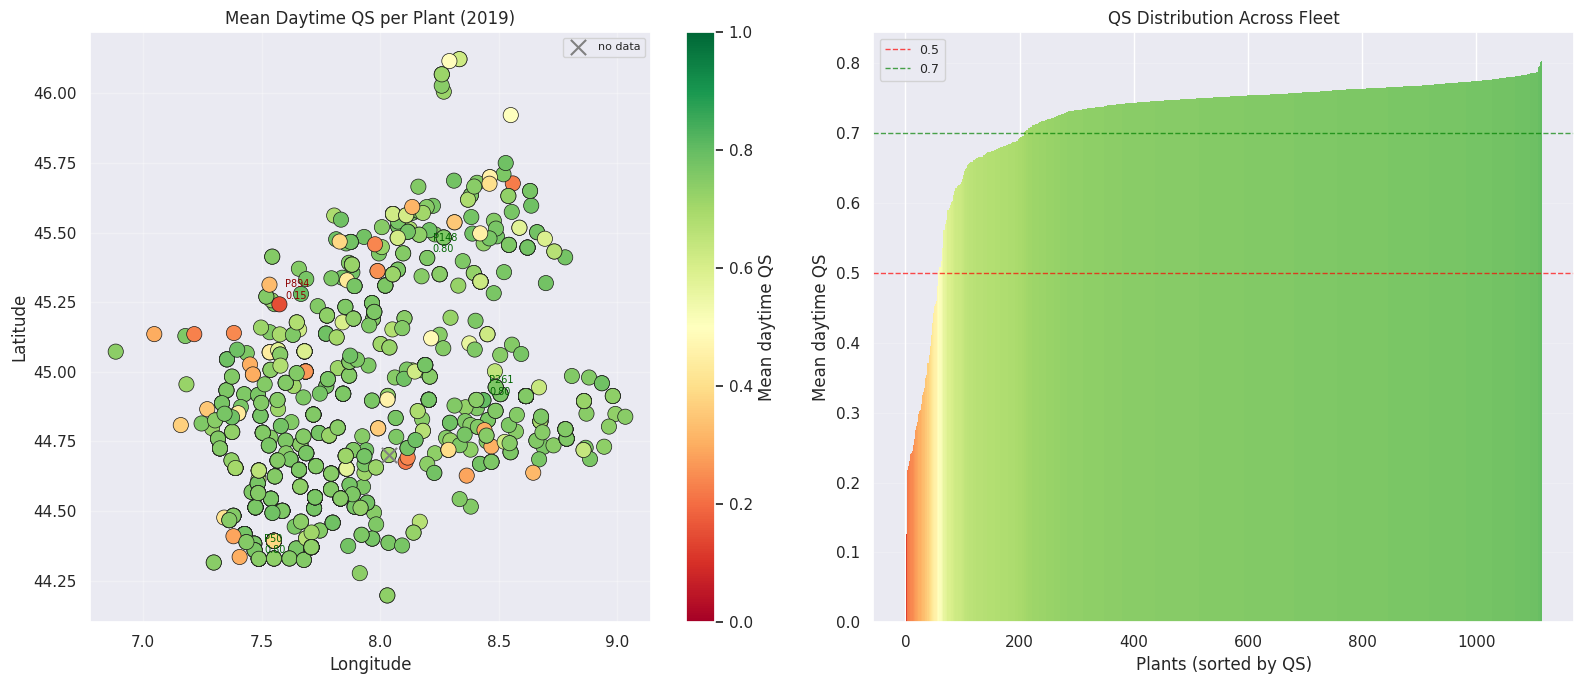

=== SPATIAL QS ===
  Top-5 plants (highest QS):
    1. Plant  148: QS=0.804  lat=45.409  lon=8.199
    2. Plant  261: QS=0.803  lat=44.898  lon=8.436
    3. Plant   50: QS=0.802  lat=44.329  lon=7.488
    4. Plant  776: QS=0.797  lat=44.545  lon=7.833
    5. Plant  638: QS=0.796  lat=44.545  lon=7.833
  Bottom-5 plants (lowest QS):
    1. Plant  946: QS=0.111  lat=nan  lon=nan
    2. Plant  846: QS=0.126  lat=nan  lon=nan
    3. Plant  894: QS=0.150  lat=45.242  lon=7.575
    4. Plant  345: QS=0.217  lat=44.677  lon=8.108
    5. Plant   47: QS=0.223  lat=45.676  lon=8.560
  Plants with no daytime data (1): [np.int64(896)]


In [7]:
# Spatial map: plants colored by mean daytime QS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: QS map (exclude NaN plants from colormap)
ax = axes[0]
valid_mask = ~np.isnan(qs_plant_mean)
sc = ax.scatter(lons[valid_mask], lats[valid_mask],
                c=qs_plant_mean[valid_mask], s=120,
                cmap='RdYlGn', vmin=0.0, vmax=1.0,
                edgecolors='k', linewidth=0.5, zorder=3)
if (~valid_mask).any():
    ax.scatter(lons[~valid_mask], lats[~valid_mask],
               s=120, c='grey', marker='x', linewidth=1.5, zorder=4, label='no data')
    ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Mean daytime QS')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mean Daytime QS per Plant (2019)')
ax.grid(True, alpha=0.3)

# Annotate top-3 and bottom-3 â€” exclude NaN
valid_idx = np.where(valid_mask)[0]
sorted_valid = valid_idx[np.argsort(qs_plant_mean[valid_idx])]
top3    = sorted_valid[-3:][::-1]
bottom3 = sorted_valid[:3]
for idx in top3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkgreen',
                xytext=(4, 4), textcoords='offset points')
for idx in bottom3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkred',
                xytext=(4, 4), textcoords='offset points')

# Right: QS distribution per plant (sorted bar)
ax2 = axes[1]
order = np.argsort(np.where(valid_mask, qs_plant_mean, -1))
colors = plt.cm.RdYlGn(np.clip(qs_plant_mean[order], 0, 1))
ax2.bar(range(N), np.where(valid_mask[order], qs_plant_mean[order], 0),
        color=colors, edgecolor='none', width=1.0)
ax2.axhline(0.5, color='red',   linestyle='--', linewidth=1, alpha=0.7, label='0.5')
ax2.axhline(0.7, color='green', linestyle='--', linewidth=1, alpha=0.7, label='0.7')
ax2.set_xlabel('Plants (sorted by QS)')
ax2.set_ylabel('Mean daytime QS')
ax2.set_title('QS Distribution Across Fleet')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

# Text: top/bottom 5 (NaN excluded)
print("=== SPATIAL QS ===")
print("  Top-5 plants (highest QS):")
for i, idx in enumerate(sorted_valid[-5:][::-1]):
    print(f"    {i+1}. Plant {idx:>4}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
print("  Bottom-5 plants (lowest QS):")
for i, idx in enumerate(sorted_valid[:5]):
    print(f"    {i+1}. Plant {idx:>4}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
if n_nan_plants > 0:
    nan_idx = np.where(~valid_mask)[0]
    print(f"  Plants with no daytime data ({n_nan_plants}): {list(nan_idx)}")

In [8]:
# Plant size estimates (kWp proxy) and per-plant PR
pv_scale_arr = dataset.pv_scale  # (N,) p99 ENERGIA daytime [kW]

# New pipeline uses irradiance-based reference (solar_p99).
# Keep fallback to legacy alias for old checkpoints/notebooks.
solar_p99_arr = getattr(dataset, "solar_p99", getattr(dataset, "pvgis_p99"))
eta_adj_arr = dataset.eta_adjusted  # (N,) per-plant eta proxy [dimensionless]

# kWp proxy estimate: p99(ENERGIA_day) / p99(solar_irradiance_poa_day[kW/m^2])
kWp_est = pv_scale_arr / solar_p99_arr  # (N,)

# PR proxy = eta_adjusted (data-driven ratio used in physics loss)
pr_actual = eta_adj_arr

print("=== PER-PLANT SIZE AND PERFORMANCE RATIO ===")
print(f"  {'Plant':>5}  {'kWp_est':>8}  {'PR':>6}  {'pv_scale':>9}  {'solar_p99':>9}  {'eta_adj':>8}")
print(f"  {'-'*5}  {'-'*8}  {'-'*6}  {'-'*9}  {'-'*9}  {'-'*8}")
for p in range(len(kWp_est)):
    print(f"  {p:>5}  {kWp_est[p]:>8.1f}  {pr_actual[p]:>6.3f}  {pv_scale_arr[p]:>9.1f}  {solar_p99_arr[p]:>9.3f}  {eta_adj_arr[p]:>8.3f}")

print(f"\n  FLEET SUMMARY:")
print(f"  kWp  - min={kWp_est.min():.1f}  max={kWp_est.max():.1f}  mean={kWp_est.mean():.1f}  median={np.median(kWp_est):.1f}")
print(f"  PR   - min={pr_actual.min():.3f}  max={pr_actual.max():.3f}  mean={pr_actual.mean():.3f}  std={pr_actual.std():.3f}")
print(f"  Note: kWp_est = p99(ENERGIA_day) / p99(solar_irradiance_poa_day)")
print(f"        PR proxy = eta_adjusted (irradiance-based, no pvgis_ref dependency)")


=== PER-PLANT SIZE AND PERFORMANCE RATIO ===
  Plant   kWp_est      PR   pv_scale  solar_p99   eta_adj
  -----  --------  ------  ---------  ---------  --------
      0     874.9   1.000      814.1      0.931     1.000
      1      71.0   0.961       66.0      0.930     0.961
      2     191.7   1.000      179.0      0.934     1.000
      3      71.4   0.909       66.0      0.925     0.909
      4      91.7   0.949       84.7      0.924     0.949
      5      67.6   1.000       63.0      0.932     1.000
      6     891.6   0.976      826.1      0.927     0.976
      7      81.2   1.000       76.2      0.939     1.000
      8      17.4   1.000       16.0      0.922     1.000
      9      64.6   0.921       60.0      0.929     0.921
     10      48.8   1.000       45.0      0.923     1.000
     11     883.9   0.975      827.4      0.936     0.975
     12     210.7   1.000      194.0      0.921     1.000
     13     521.8   1.000      491.9      0.943     1.000
     14    2371.6   0.828  